## Setup

In [1]:
import sys
from pathlib import Path

# Add project root ke sys.path biar bisa import src
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy


In [2]:
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import shap
import joblib
import mlflow
import mlflow.xgboost
import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

from src.data.data_loader import DataLoader
from src.data.data_processing import DataProcessor

# Setup MLflow
mlflow.set_tracking_uri(f"file:{ROOT / 'mlruns'}")
mlflow.set_experiment("coffee_location_demand")

# Folder model
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"MLflow tracking: {ROOT / 'mlruns'}")

/Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/mlruns


/Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## Load Data

In [3]:
clean_path = ROOT / 'data' / 'clean'
processed_path = ROOT / 'data' / 'processed'
processed_path.mkdir(parents=True, exist_ok=True)

In [4]:
df_cafe = pd.read_csv(clean_path / 'cafes_clean.csv')
df_owner = pd.read_csv(clean_path / 'owner_clean.csv')

print(f"Cafes:  {len(df_cafe)}")
print(f"Owner:  {len(df_owner)}")

poi = {}
for cat in ['office', 'mall', 'transit', 'school']:
    f = clean_path / f'osm_{cat}_clean.csv'
    poi[cat] = pd.read_csv(f)
    print(f"poi {cat:8s}: {len(poi[cat])}")


Cafes:  1843
Owner:  16
poi office  : 3782
poi mall    : 637
poi transit : 4627
poi school  : 6387


In [5]:
df_train = pd.read_csv(processed_path / 'features.csv')
print(f"Shape of data: {df_train.shape}")
df_train.head(5)

Shape of data: (1843, 26)


,n_competitors_500m,avg_competitor_rating_500,total_competitor_reviews_500,max_competitor_reviews_500,n_competitors_2km,avg_competitor_rating_2km,total_competitor_reviews_2km,max_competitor_reviews_2km,nearest_owner_store_m,n_offices_500m,...,n_schools_2km,target,cafe_id,cafe_name,lat,lng,rating_cafe,reviews_count_cafe,kecamatan,kota
0,7,4.2,3259,2361,97,4.6,78027,6181,2118.00,24,...,115,27.856419,ChIJk2S-5gT1aS4R7BfG9zPTqeg,Stroom Coffee,-6.180408,106.832789,4.5,487,Gambir,Jakarta Pusat
1,5,4.8,5481,5032,95,4.6,51215,5032,2531.54,20,...,100,40.221468,ChIJM-y5dv_3aS4Ru5vfq9j1HK4,Kopi Nako,-6.172734,106.821282,4.7,5206,Gambir,Jakarta Pusat
2,5,4.7,1314,817,105,4.6,53272,5206,2984.80,16,...,115,32.193144,ChIJ_YWVAtP1aS4RP0dLZugFvDg,21 Factory Gelato & Coffee,-6.170070,106.829746,4.6,1094,Gambir,Jakarta Pusat
3,2,4.6,842,691,78,4.7,30902,5206,3243.30,17,...,126,29.160201,ChIJGRmYnyj3aS4RBrjMwAep-HE,9 GRAMS,-6.167211,106.813952,4.5,651,Gambir,Jakarta Pusat
4,10,4.2,3605,2361,113,4.6,78070,6181,2247.20,15,...,106,24.433022,ChIJp8FIVeL1aS4RTQt9O2sb8Gg,Loko Cafe Gambir,-6.177873,106.831042,4.4,257,Gambir,Jakarta Pusat


## Derivative Features

Tambah engineered features dari kombinasi raw features.

In [6]:
# Avoid division by zero
df_train['density_ratio_500m_2km'] = (
    df_train['n_competitors_500m'] / (df_train['n_competitors_2km'] + 1)
)

df_train['avg_reviews_per_cafe_2km'] = (
    df_train['total_competitor_reviews_2km'] / (df_train['n_competitors_2km'] + 1)
)

df_train['market_saturation'] = (
    df_train['n_competitors_500m'] * df_train['avg_competitor_rating_2km']
)

df_train['office_transit_combo'] = (
    df_train['n_offices_500m'] * df_train['n_transit_500m']
)

df_train['has_strong_competitor'] = (
    df_train['max_competitor_reviews_2km'] > 1000
).astype(int)

df_train['anchor_score'] = (
    df_train['n_malls_2km'] * 0.5 + df_train['n_transit_500m'] * 1.0
)

print(f"Total features after derivative: {df_train.shape[1] - 4}")
print("Sample new features:")
df_train[['density_ratio_500m_2km', 'avg_reviews_per_cafe_2km',
          'market_saturation', 'office_transit_combo',
          'has_strong_competitor', 'anchor_score']].describe()

Total features after derivative: 28
Sample new features:


,density_ratio_500m_2km,avg_reviews_per_cafe_2km,market_saturation,office_transit_combo,has_strong_competitor,anchor_score
count,1843.000000,1843.000000,1843.000000,1843.000000,1843.000000,1843.000000
mean,0.123444,401.021222,32.159468,70.991319,0.861639,13.749050
std,0.092661,261.774530,26.601790,98.789832,0.345373,8.077249
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.054300,208.067142,9.400000,8.000000,1.000000,7.500000
50%,0.106667,331.088496,27.600000,35.000000,1.000000,13.000000
75%,0.179487,548.677590,46.000000,96.000000,1.000000,19.500000
max,0.500000,1498.047619,131.600000,832.000000,1.000000,37.500000


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843 entries, 0 to 1842
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   n_competitors_500m            1843 non-null   int64  
 1   avg_competitor_rating_500     1843 non-null   float64
 2   total_competitor_reviews_500  1843 non-null   int64  
 3   max_competitor_reviews_500    1843 non-null   int64  
 4   n_competitors_2km             1843 non-null   int64  
 5   avg_competitor_rating_2km     1843 non-null   float64
 6   total_competitor_reviews_2km  1843 non-null   int64  
 7   max_competitor_reviews_2km    1843 non-null   int64  
 8   nearest_owner_store_m         1843 non-null   float64
 9   n_offices_500m                1843 non-null   int64  
 10  n_offices_2km                 1843 non-null   int64  
 11  n_malls_500m                  1843 non-null   int64  
 12  n_malls_2km                   1843 non-null   int64  
 13  n_t

## EDA

Features (23):
  - n_competitors_500m
  - avg_competitor_rating_500
  - total_competitor_reviews_500
  - max_competitor_reviews_500
  - n_competitors_2km
  - avg_competitor_rating_2km
  - total_competitor_reviews_2km
  - max_competitor_reviews_2km
  - nearest_owner_store_m
  - n_offices_500m
  - n_offices_2km
  - n_malls_500m
  - n_malls_2km
  - n_transit_500m
  - n_transit_2km
  - n_schools_500m
  - n_schools_2km
  - density_ratio_500m_2km
  - avg_reviews_per_cafe_2km
  - market_saturation
  - office_transit_combo
  - has_strong_competitor
  - anchor_score


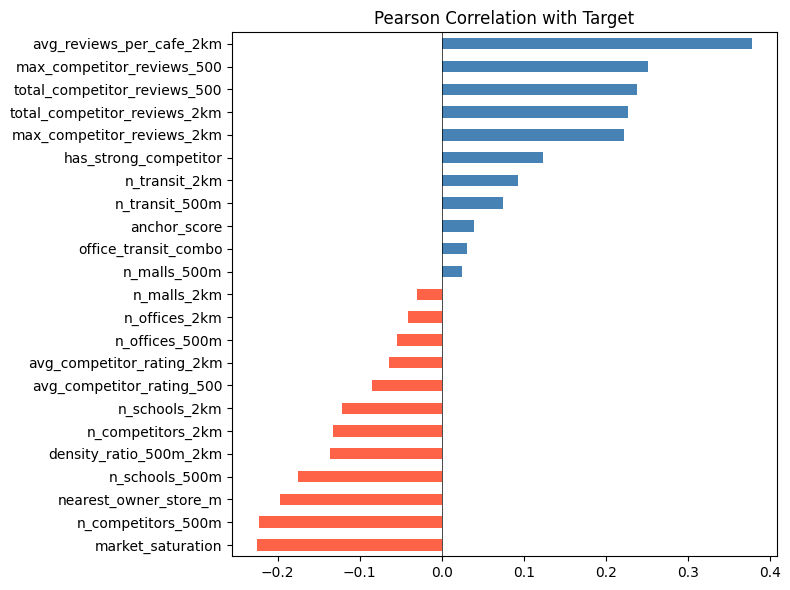

In [8]:
feature_cols = df_train.drop(columns=['cafe_id', 'cafe_name', 'kecamatan', 'kota', 'lat', 'lng', 'target', 'rating_cafe', 'reviews_count_cafe']).columns.tolist()

print(f"Features ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  - {f}")

# Correlation with target
corr = df_train[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot.barh(ax=ax, color=corr.apply(lambda x: 'steelblue' if x > 0 else 'tomato'))
ax.set_title('Pearson Correlation with Target')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Train/Test Split

In [9]:
X = df_train[feature_cols].fillna(0)
y = df_train['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"y_test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}")

X_train: (1474, 23)
X_test:  (369, 23)
y_train: mean=22.12, std=7.86
y_test:  mean=22.71, std=7.82


## Train Baseline XGBoost

In [10]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        'r2': float(r2_score(y_test, pred)),
        'mae': float(mean_absolute_error(y_test, pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_test, pred))),
        'spearman': float(spearmanr(y_test, pred).correlation),
    }

with mlflow.start_run(run_name="baseline_bayes_target"):
    params = {
        'n_estimators': 500,
        'max_depth': 6,
        'learning_rate': 0.05,
        'random_state': 42,
    }
    mlflow.log_params(params)
    mlflow.log_param('target_type', 'bayesian_adjusted')
    mlflow.log_param('n_features', len(feature_cols))
    mlflow.log_param('confidence_M', 50)
    
    model_base = xgb.XGBRegressor(**params)
    model_base.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    metrics = evaluate(model_base, X_test, y_test)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(model_base, 'model', input_example=X_train.head(2))
    
    print("Baseline:")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")

2026/05/31 13:57:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Baseline:
  r2        : 0.2620
  mae       : 5.3740
  rmse      : 6.7103
  spearman  : 0.5034


## Optuna Hyperparameter Tuning

In [11]:
N_TRIALS = 20  # naikkan kalau timeline cukup

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
    }
    
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=False):
        mlflow.log_params(params)
        
        m = xgb.XGBRegressor(**params)
        m.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        
        metrics = evaluate(m, X_test, y_test)
        mlflow.log_metrics(metrics)
        
        return metrics['mae']

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest MAE: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-31 13:57:33,177] A new study created in memory with name: no-name-13b8f73f-2d75-44a2-a518-12eb1831142e
Best trial: 0. Best value: 5.3084:   5%|▌         | 1/20 [00:02<00:43,  2.28s/it]

[I 2026-05-31 13:57:35,505] Trial 0 finished with value: 5.308399438215283 and parameters: {'n_estimators': 819, 'max_depth': 9, 'learning_rate': 0.09294167110101564, 'subsample': 0.7597804326181627, 'colsample_bytree': 0.9395918673563413, 'reg_alpha': 4.214677109192653, 'reg_lambda': 0.8789605012886631}. Best is trial 0 with value: 5.308399438215283.


Best trial: 1. Best value: 5.21103:  15%|█▌        | 3/20 [00:04<00:20,  1.19s/it]

[I 2026-05-31 13:57:37,431] Trial 1 finished with value: 5.21103143831429 and parameters: {'n_estimators': 850, 'max_depth': 7, 'learning_rate': 0.0125521146642738, 'subsample': 0.6388247832338533, 'colsample_bytree': 0.6154236069235713, 'reg_alpha': 1.0933881878531886, 'reg_lambda': 3.979036531548006}. Best is trial 1 with value: 5.21103143831429.
[I 2026-05-31 13:57:37,572] Trial 2 finished with value: 5.344627244527553 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.08161910321567847, 'subsample': 0.8299299725396523, 'colsample_bytree': 0.9517779337621795, 'reg_alpha': 1.537696768092693, 'reg_lambda': 4.000640409171882}. Best is trial 1 with value: 5.21103143831429.


Best trial: 1. Best value: 5.21103:  20%|██        | 4/20 [00:05<00:15,  1.01it/s]

...

[I 2026-05-31 13:58:02,458] Trial 17 finished with value: 5.233422966283266 and parameters: {'n_estimators': 657, 'max_depth': 8, 'learning_rate': 0.055213189982802946, 'subsample': 0.8859899667344757, 'colsample_bytree': 0.7849036150890634, 'reg_alpha': 3.184455726335074, 'reg_lambda': 2.085032257240438}. Best is trial 6 with value: 5.157780163993972.


Best trial: 6. Best value: 5.15778:  95%|█████████▌| 19/20 [00:30<00:01,  1.54s/it]

[I 2026-05-31 13:58:04,087] Trial 18 finished with value: 5.237676642754741 and parameters: {'n_estimators': 453, 'max_depth': 9, 'learning_rate': 0.058071173677431205, 'subsample': 0.7118735175655116, 'colsample_bytree': 0.8866761438183528, 'reg_alpha': 4.140127182599983, 'reg_lambda': 0.9918188183421941}. Best is trial 6 with value: 5.157780163993972.


Best trial: 6. Best value: 5.15778: 100%|██████████| 20/20 [00:31<00:00,  1.57s/it]

[I 2026-05-31 13:58:04,680] Trial 19 finished with value: 5.323850053868542 and parameters: {'n_estimators': 249, 'max_depth': 6, 'learning_rate': 0.0273969113056753, 'subsample': 0.9986338620005778, 'colsample_bytree': 0.6475036703837576, 'reg_alpha': 4.826249936199977, 'reg_lambda': 4.942969924080182}. Best is trial 6 with value: 5.157780163993972.

Best MAE: 5.1578
Best params:
  n_estimators: 464
  max_depth: 8
  learning_rate: 0.07966065295076956
  subsample: 0.9536901966489443
  colsample_bytree: 0.6418219820212382
  reg_alpha: 4.68636253881738
  reg_lambda: 0.044047620858628234


## Final Model dengan Best Params

In [13]:
from sklearn.model_selection import KFold
best_params = study.best_params
best_params['random_state'] = 42

with mlflow.start_run(run_name="final_best_model"):
    mlflow.log_params(best_params)
    mlflow.log_param('selection_method', 'optuna_best')
    
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    verbose=False)
    
    metrics = evaluate(final_model, X_test, y_test)
    mlflow.log_metrics(metrics)
    
    # CV stability
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(final_model, X, y, cv=kf, scoring='r2')
    cv_mae = -cross_val_score(final_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

    mlflow.log_metric('cv_r2_mean', float(cv_r2.mean()))
    mlflow.log_metric('cv_r2_std', float(cv_r2.std()))
    mlflow.log_metric('cv_mae_mean', float(cv_mae.mean()))
    
    mlflow.xgboost.log_model(final_model, 'best_model', input_example=X_train.head(2))
    final_run_id = mlflow.active_run().info.run_id
    
    print("FINAL MODEL")
    print("=" * 50)
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print(f"  cv_r2     : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"  cv_mae    : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")

2026/05/31 13:58:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


FINAL MODEL
  r2        : 0.3240
  mae       : 5.1578
  rmse      : 6.4220
  spearman  : 0.5486
  cv_r2     : 0.2448 ± 0.0483
  cv_mae    : 5.4280 ± 0.1803


## SHAP Analysis

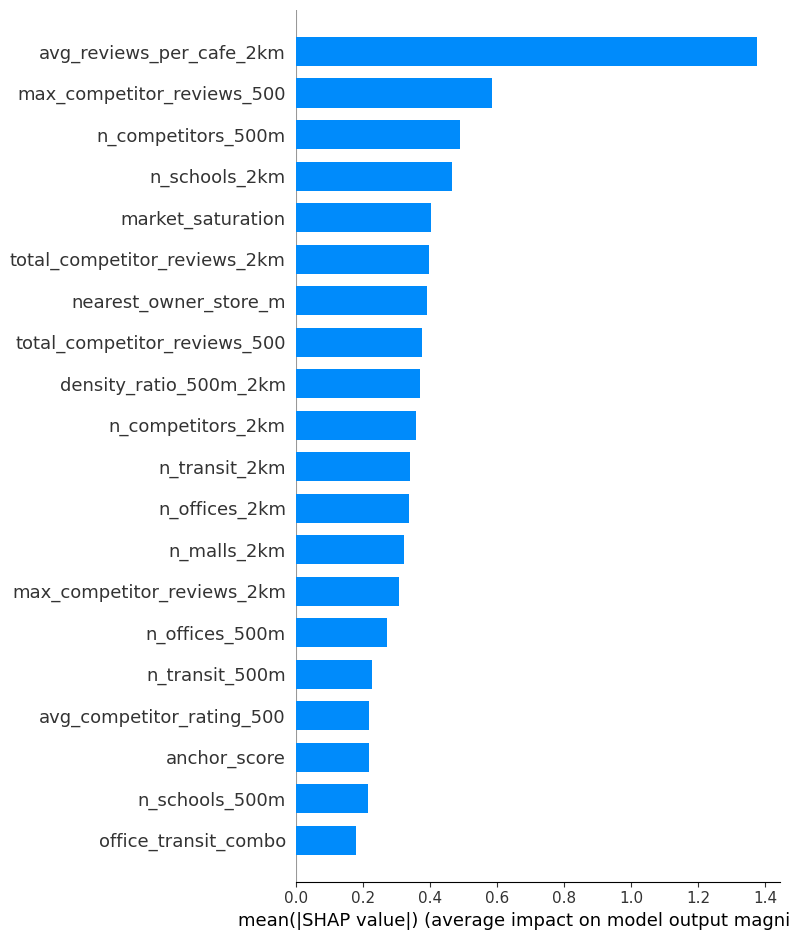

In [14]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — feature importance
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_importance_bar.png', dpi=100, bbox_inches='tight')
plt.show()

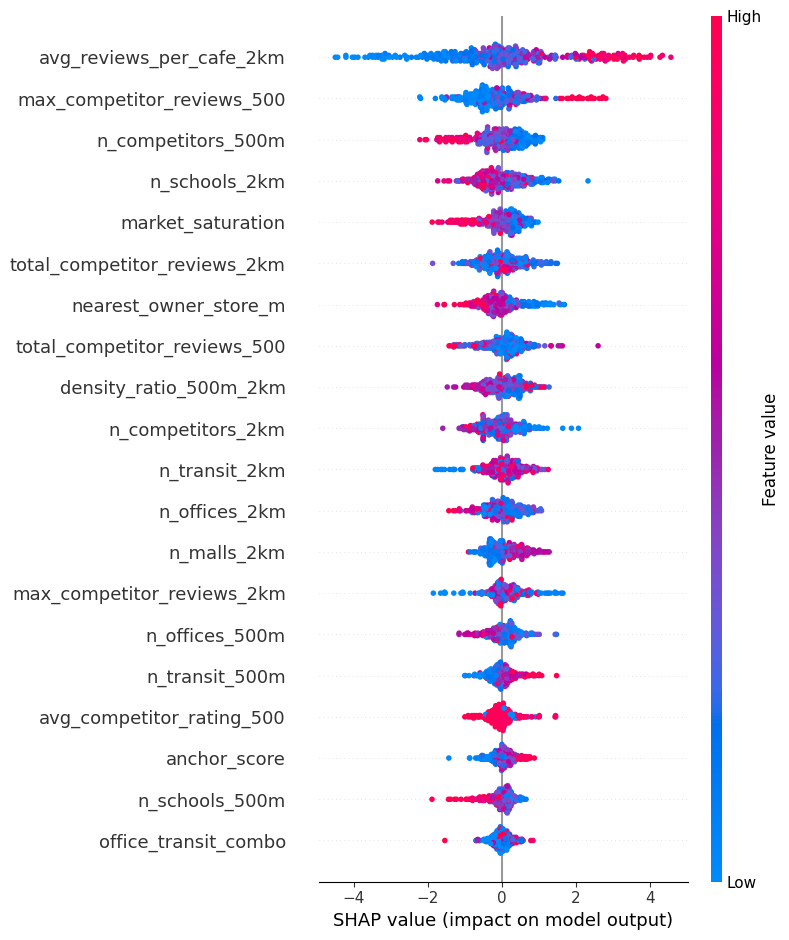

In [15]:
# Summary plot — dengan distribusi value
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
# Example penjelasan 1 prediksi (cafe pertama di test set)
idx = 0
print(f"Penjelasan prediksi untuk cafe ke-{idx}:")
print(f"  Actual: {y_test.iloc[idx]:.2f}")
print(f"  Predicted: {final_model.predict(X_test.iloc[idx:idx+1])[0]:.2f}")
print(f"\nTop 5 contributing features:")

contrib = dict(zip(feature_cols, shap_values[idx]))
top5 = sorted(contrib.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
for f, v in top5:
    direction = "↑" if v > 0 else "↓"
    print(f"  {direction} {f}: SHAP {v:+.3f} (value={X_test.iloc[idx][f]:.2f})")

Penjelasan prediksi untuk cafe ke-0:
  Actual: 29.28
  Predicted: 24.16

Top 5 contributing features:
  ↑ avg_reviews_per_cafe_2km: SHAP +0.858 (value=549.83)
  ↑ n_schools_2km: SHAP +0.728 (value=84.00)
  ↑ total_competitor_reviews_500: SHAP +0.622 (value=1436.00)
  ↓ nearest_owner_store_m: SHAP -0.573 (value=6856.69)
  ↑ n_competitors_2km: SHAP +0.523 (value=22.00)


## Save Model dan Metadata

In [17]:
# Save model (joblib format, dipakai Streamlit)
model_artifact = {
    'model': final_model,
    'feature_cols': feature_cols,
    'params': best_params,
}
joblib.dump(model_artifact, MODEL_DIR / 'xgb_demand.pkl')
print(f"✓ Model saved: {MODEL_DIR / 'xgb_demand.pkl'}")

# Save feature columns
(MODEL_DIR / 'feature_columns.json').write_text(
    json.dumps(feature_cols, indent=2)
)
print(f"✓ Feature columns saved")

# Save metadata
meta = {
    'trained_at': datetime.now().isoformat(),
    'mlflow_run_id': final_run_id,
    'best_params': best_params,
    'metrics': metrics,
    'cv_metrics': {
        'r2_mean': float(cv_r2.mean()),
        'r2_std': float(cv_r2.std()),
        'mae_mean': float(cv_mae.mean()),
    },
    'n_train': len(X_train),
    'n_test': len(X_test),
    'n_features': len(feature_cols),
    'feature_cols': feature_cols,
    'target_type': 'bayesian_adjusted_rating_x_log_reviews',
    'confidence_M': 50,
}
(MODEL_DIR / 'model_meta.json').write_text(json.dumps(meta, indent=2))
print(f"✓ Metadata saved: {MODEL_DIR / 'model_meta.json'}")

✓ Model saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/models/xgb_demand.pkl
✓ Feature columns saved
✓ Metadata saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/models/model_meta.json


## Save Training Features

In [18]:
features_out = ROOT / 'data' / 'processed' / 'features.csv'
features_out.parent.mkdir(parents=True, exist_ok=True)
df_train.to_csv(features_out, index=False)
print(f"✓ Features saved: {features_out}")
print(f"  Shape: {df_train.shape}")

✓ Features saved: /Users/ratamate/Documents/Project Pribadi/Project Akhir - DIbimbing copy/data/processed/features.csv
  Shape: (1843, 32)
